## Implémentation du solveur de Helmholtz 2D en configuration bipériodique, avec CLs de Dirichlet

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr

import matplotlib.colors as colors

#module "maison"
import Chebyshev

In [3]:
Chebyshev.Cheb_mat(8).shape

(8, 8)

On résout 
$$
\left(\partial_y^2+\partial_x^2-\alpha^2\right)\psi(x, y) = RHS(x, y)
$$
sur $x, y \in [-1, 1]$, avec $\psi(x, y=\pm 1) = \pm \cosh(l)\cos(kx)$. La solution est $\psi(x, y) = \cos(kx)\cosh(ly)$ pour $\alpha^2 = k^2-l^2$ et $RHS = \left(l^2 -k^2 - \alpha^2\right)\cos{kx}\cosh{ly}$
Ici, $\alpha^2 = 3$, $k=2$, $l=1$, ce qui donne $RHS = -6\cos{kx}\cosh{ly}$


Au début, on prends $\psi(x, y) = \cosh(y)$, $\psi(x, \pm 1) = \pm \cosh(1)$, $\alpha = 2$, $RHS(x, y) = -\cosh(y)$

In [68]:
def Solve_Helmholtz(Nx,
                    Ny,
                    alpha2 = 0.0,
                    rhs=0.0,
                    CL_y_inf = 0.0,
                    CL_y_sup = 0.0,
                    interval_x = (0.0, 2.0*np.pi),
                    interval_y = (-1.0, 1.0) ): 
    #génération de la grille
    x = np.linspace(interval_x[0], interval_x[1], Nx, endpoint = False)
    y = Chebyshev.collocation_points(Ny, a = interval_y[0], b = interval_y[1])
    #print(f"y = {y}")
    kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (interval_x[-1] - interval_x[0])/Nx)
    print(f"kx = {kx}")
    if np.isscalar(rhs) : 
        print(f"RHS scalar")
        rhs = rhs *np.ones((Nx, Ny))
    elif isinstance(rhs, np.ndarray) and (rhs.shape[0] == Nx or rhs.shape[1] == Ny) : 
        print("RHS array")
    else:
        raise ValueError(f"rhs must be of size Nx x Ny (rhs.shape = {rhs.shape})")
    
    psi_num = np.zeros((Nx, Ny))
    psi_num_hat = np.zeros((Nx, Ny), dtype = 'complex')
    rhs_hat = scipy.fft.fft(rhs, axis = 0)
    
    
    D = Chebyshev.Cheb_mat(Ny, a = interval_y[0], b = interval_y[1])
    D2 = D@D
    
    if np.isscalar(CL_y_inf) : 
        BC_y_inf = np.ones(Nx) * CL_y_inf
        print("CL_inf scalar")
    elif ( isinstance(CL_y_inf, np.ndarray) == True ) and ( CL_y_inf.shape[0] == Nx and len(CL_y_inf.shape) == 1 ): 
        print("CL_inf array")
        BC_y_inf = CL_y_inf.copy()
    else : 
        raise ValueError(f"CL_y_inf must be scalar or 1D array of size Nx (CL_y_inf = {CL_y_inf}")

    if np.isscalar(CL_y_sup) : 
        print("CL_sup_scalar")
        BC_y_sup = np.ones(Nx) * CL_y_sup
    elif ( isinstance(CL_y_sup, np.ndarray) == True ) and ( CL_y_sup.shape[0] == Nx and len(CL_y_sup.shape) == 1 ): 
        print("CL_sup array")
        BC_y_sup = CL_y_sup.copy()
    else : 
        raise ValueError(f"CL_y_sup must be scalar or 1D array of size Nx (CL_y_sup = {CL_y_sup}")

    BC_y_inf_hat = scipy.fft.fft(BC_y_inf)
    BC_y_sup_hat = scipy.fft.fft(BC_y_sup)

    alpha2_id = alpha2 * np.eye(Ny)
    
    for i in range(0, Nx):
        kx_i = kx[i]
        rhs_hat_i = rhs_hat[i, :].copy()
        F = -( alpha2 + kx_i**2 )*np.eye(Ny)
        F[0, 0] = 1.0
        F[-1, -1] = 1.0
        F[1:-1, :] += D2[1:-1, :]

        inv_F = np.linalg.inv(F)
        
        
        BC_hat_inf_i = BC_y_inf_hat[i].copy()
        BC_hat_sup_i = BC_y_sup_hat[i].copy()

        rhs_hat_i[0] = BC_hat_sup_i
        rhs_hat_i[-1] = BC_hat_inf_i

        psi_hat_i = inv_F @ rhs_hat_i
        psi_num_hat[i, :] = psi_hat_i
    
    psi_num = scipy.fft.ifft(psi_num_hat, axis = 0).real
    
    return psi_num
    

Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0
kx = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62. -61. -60. -59.
 -58. -57. -56. -55. -54. -53. -52. -51. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]
RHS array
CL_inf array
CL_sup array
err [[2.63167266e-12 2.63233879e-12 2.62945221e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]
 [2.63167266e-12 2.63233879e-12 2.62945221e-12 ... 2.22044605e-16
  2.22044605e-16 0.00000000e+00]
 [2.63167266e-12 2.63233879e-12 2.6294

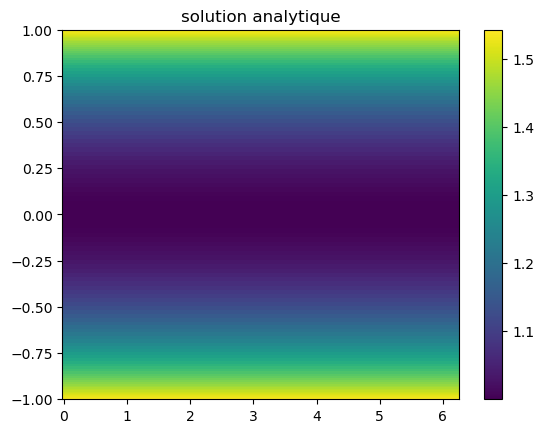

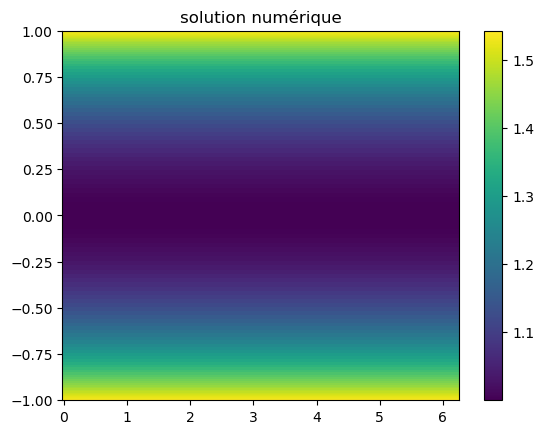

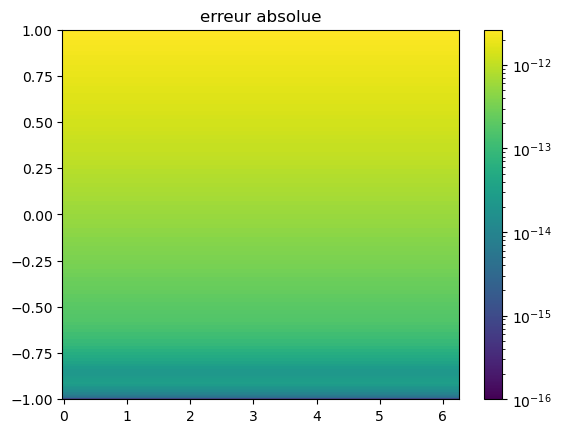

In [69]:
#cas 1D avec psi(x, y) = cosh(y), alpha^2 = 2, rhs = -cosh(y)
Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2 = 2.*l**2

print(f'alpha^2 {alpha2}')

rhs = -np.cosh(l*Y)

bc_y1 = np.cosh(l) * np.ones(Nx)
bc_ym1 = bc_y1.copy()


psi_analytique = np.cosh(l*Y)

psi_num = Solve_Helmholtz(Nx,
                          Ny,
                          alpha2 = alpha2,
                          rhs = rhs,
                          CL_y_inf = bc_ym1,
                          CL_y_sup = bc_y1,
                          interval_x = (x_inf, x_sup),
                          interval_y = (y_inf, y_sup))

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num)
fig.colorbar(cf, ax=ax)

err = np.abs(psi_analytique - psi_num)
print(f"err {err}, min = {err.min()}, max = {err.max()}, mediane = {np.median(err)}")

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err, norm=colors.LogNorm(vmin=1.0e-16, vmax=err.max()))
fig.colorbar(cf, ax=ax)



Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0
kx = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62. -61. -60. -59.
 -58. -57. -56. -55. -54. -53. -52. -51. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]
RHS array
CL_inf array
CL_sup array


'\nerr_rhs = np.abs(err_rhs  -RHS_comp)\n\nfig  = plt.figure()\nax=plt.axes()\nax.set_title("erreur absolue")\ntry:\n    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=err_rhs.min(), vmax=err_rhs.max()))\nexcept ValueError:\n    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_rhs.max()))\nfig.colorbar(cf, ax=ax)\n'

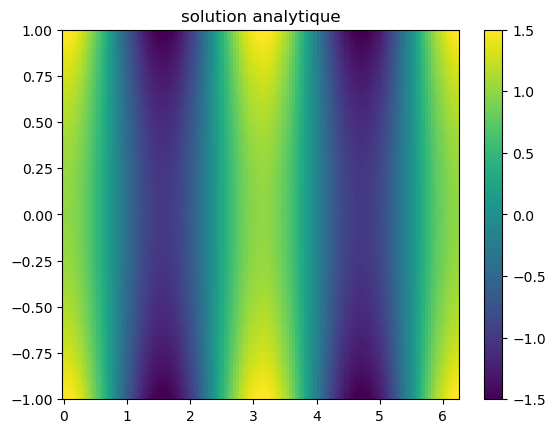

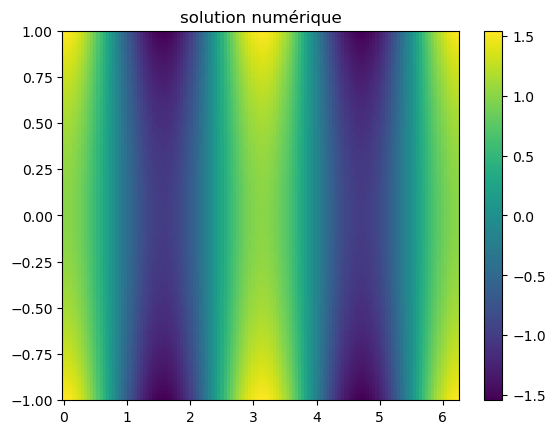

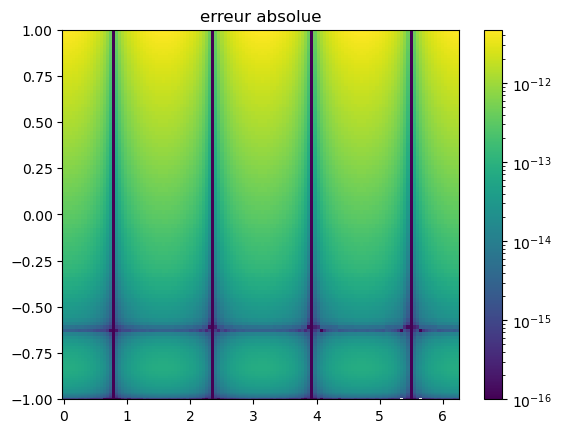

In [70]:
#Cas avec psi(x, y) = 

Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2_2 = 3.0

print(f'alpha^2 {alpha2}')

bc_y1_2 = np.cos(k*x)*np.cosh(l)
bc_ym1_2 = np.cos(k*x)*np.cosh(l)

#bc_y1_2 = np.cos(k*x)*np.sinh(l)
#bc_ym1_2 = -np.cos(k*x)*np.sinh(l)



psi_analytique_2 = np.cos(k*X)*np.cosh(l*Y)
#psi_analytique_2 = np.cos(k*X)*np.sinh(l*Y)

rhs_2 = (l**2-k**2-alpha2_2)*np.cos(k*X)*np.cosh(l*Y)
#rhs_2 = -6.0*np.cos(k*X)*np.sinh(l*Y)
#rhs_2 = np.zeros((Nx, Ny))

psi_num_2 = Solve_Helmholtz(Nx,
                            Ny,
                            alpha2 = alpha2_2,
                            rhs = rhs_2,
                            CL_y_inf = bc_ym1_2,
                            CL_y_sup = bc_y1_2,
                            interval_x = (x_inf, x_sup),
                            interval_y = (y_inf, y_sup)
                           )
"""
RHS_comp = (Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =0, a = x_inf, b = x_sup)+
            Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =1, a = y_inf, b = y_sup) - alpha2_2 * psi_analytique_2)
"""
VMAX = max(psi_analytique_2.max(), psi_num_2.max())
VMIN = min(psi_analytique_2.min(), psi_num_2.min())

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique_2, vmin = -1.5, vmax = 1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num_2, vmin = VMIN, vmax = VMAX)
fig.colorbar(cf, ax=ax)

err_2 = np.abs(psi_analytique_2 - psi_num_2)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)
"""
err_rhs = np.abs(err_rhs  -RHS_comp)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
try:
    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=err_rhs.min(), vmax=err_rhs.max()))
except ValueError:
    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_rhs.max()))
fig.colorbar(cf, ax=ax)
"""

Text(0, 0.5, '$\\psi(x, y_0)$')

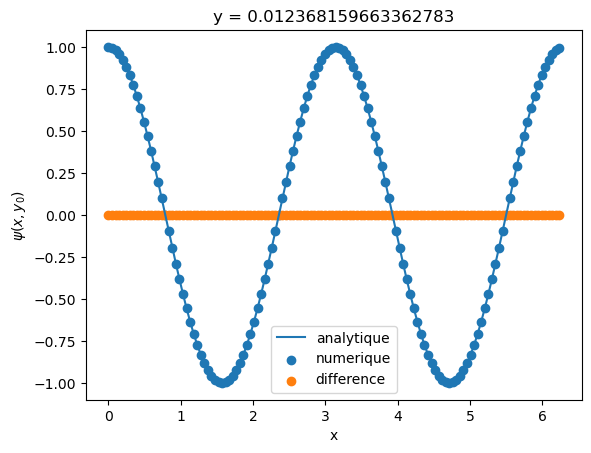

In [64]:
#cas en y = 0
y_0 = 0.0
y_index = np.abs(y - y_0).argmin()

y_sel = y[y_index]
psi_ana_y = psi_analytique_2[:, y_index]
psi_num_y = psi_num_2[:, y_index]

fig = plt.figure()
plt.title(f"y = {y_sel}")
plt.plot(x, psi_ana_y, label = 'analytique')
plt.scatter(x, psi_num_y, label = 'numerique')
plt.scatter(x, psi_ana_y - psi_num_y, label ='difference')
plt.legend()
plt.xlabel('x')
plt.ylabel(r"$\psi(x, y_0)$")


Text(0, 0.5, '$\\epsilon$')

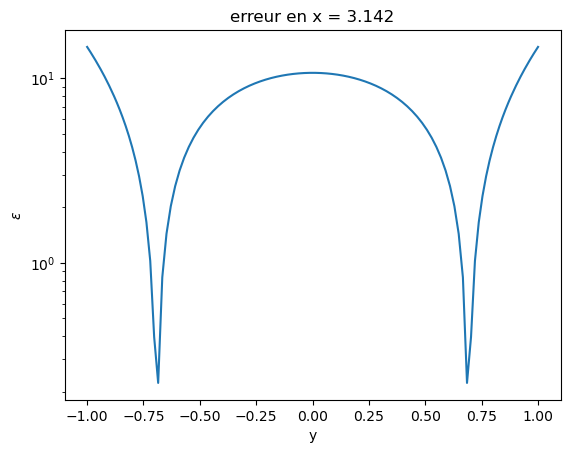

In [8]:
#cas en x = pi
x_sel = np.pi
id_x = np.abs(x-x_sel).argmin()

err_x = np.abs(psi_num_2[id_x, :] - psi_analytique_2[id_x, :])
fig = plt.figure()
plt.title(f"erreur en x = {x[id_x]:.3f}")
plt.semilogy(y, err_x)
plt.xlabel("y")
plt.ylabel(r'$\epsilon$')

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62. -61. -60. -59.
 -58. -57. -56. -55. -54. -53. -52. -51. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]
mode en kx = 2.0
mode en kx = -2.0


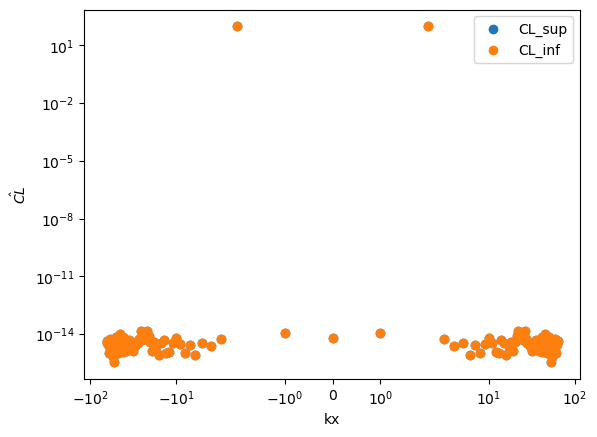

In [9]:
kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (x_sup - x_inf)/Nx)

print(kx)

CL_sup_hat = np.abs(scipy.fft.fft(bc_y1_2))
CL_inf_hat = np.abs(scipy.fft.fft(bc_ym1_2))
def sort_k(z_hat,K):
    new_z_hat = z_hat.copy()

    K_argsort = np.argsort(K)
    for i in range(0, z_hat.shape[0]):
        new_z_hat[i] = z_hat[K_argsort[i]]
    return new_z_hat

kx_sorted = np.sort(kx)
fig = plt.figure()
plt.scatter(kx_sorted, sort_k(CL_sup_hat, kx), label = r"CL_sup")
plt.scatter(kx_sorted, sort_k(CL_inf_hat, kx), label = r"CL_inf")

plt.xlabel("kx")
plt.ylabel(r"$\hat{CL}$")
plt.legend()
plt.xscale('symlog')
plt.yscale('log')


for i in range(0, kx.size) : 
    if CL_sup_hat[i] > 1.0e-10 : 
        print(f"mode en kx = {kx[i]}")

Text(0, 0.5, '$|\\hat{\\psi_{ana}} - \\hat{\\psi_{num}}|$')

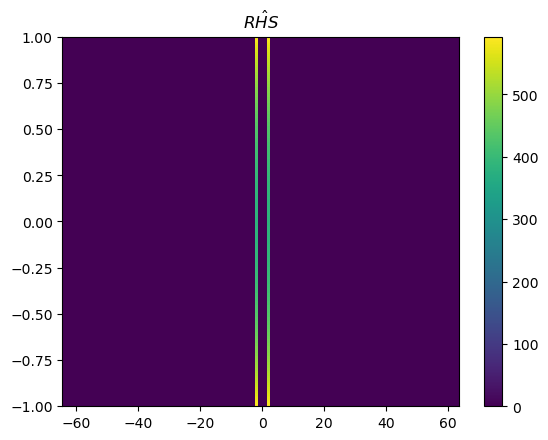

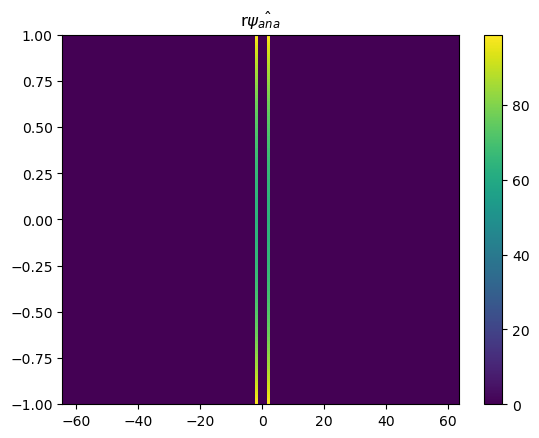

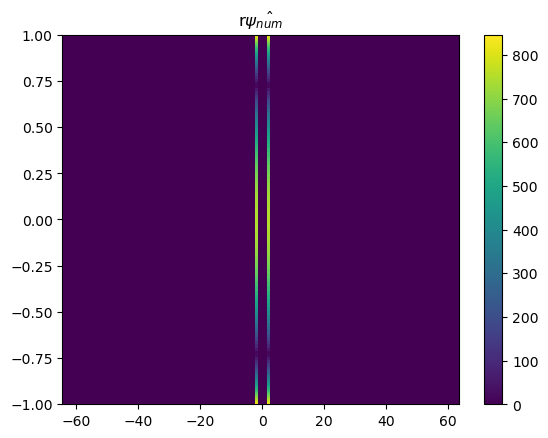

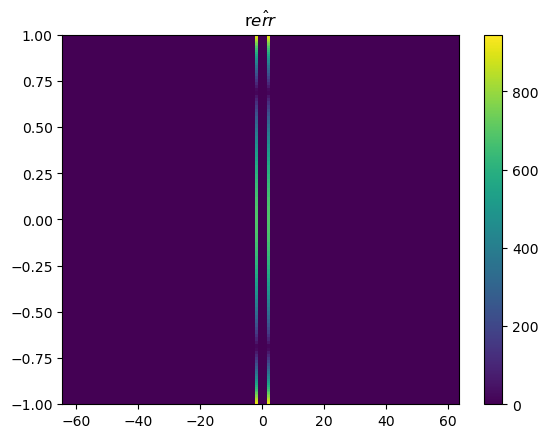

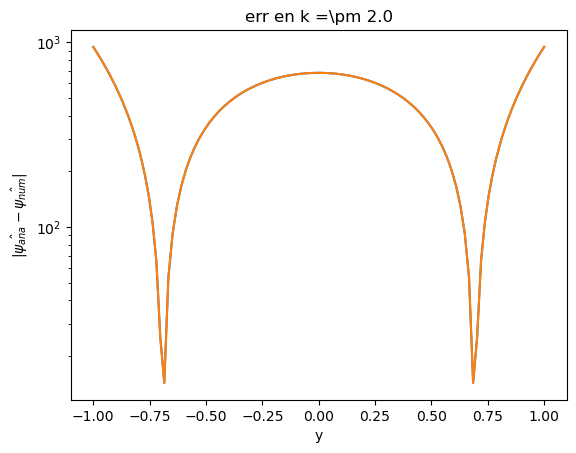

In [10]:
rhs_hat_2 = scipy.fft.fft(rhs_2, axis = 0)
Kx, Y = np.meshgrid(np.sort(kx), y, indexing = 'ij')



fig = plt.figure()
ax=plt.axes()
ax.set_title(r"$\hat{RHS}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(rhs_hat_2, kx)))
fig.colorbar(cf, ax=ax)

psi_ana_hat = scipy.fft.fft(psi_analytique_2, axis =0)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{\psi_{ana}}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(psi_ana_hat, kx)))
fig.colorbar(cf, ax=ax)

psi_num_hat_2 = scipy.fft.fft(psi_num_2, axis =0)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{\psi_{num}}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(psi_num_hat_2, kx)))
fig.colorbar(cf, ax=ax)

err_hat = scipy.fft.fft(psi_num_2 - psi_analytique_2, axis = 0)
fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{err}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(err_hat, kx)))
fig.colorbar(cf, ax=ax)

fig = plt.figure()
plt.title(fr"err en k =\pm {k}")
plt.plot(y, np.abs(err_hat[kx==k][0]), label = f"k={k}")
plt.plot(y, np.abs(err_hat[kx==-k][0]), label = f"k = -{k}")
plt.yscale('log')
plt.xlabel("y")
plt.ylabel(r"$|\hat{\psi_{ana}} - \hat{\psi_{num}}|$")

In [31]:
k_sel = k

rhs_modes = rhs_hat_2[kx==k_sel][0]

D2_psi_y = (l**2)*psi_analytique_2
k2_psi = -k**2*psi_analytique_2
alpha2_psi = -alpha2_2  * psi_analytique_2

D2_psi_hat = scipy.fft.fft(D2_psi_y, axis = 0)[kx==k_sel][0, :]

alpha2_psi_hat = scipy.fft.fft(alpha2_psi, axis = 0)[kx==k_sel][0, :]

k2_psi_hat = scipy.fft.fft(k2_psi, axis = 0)[kx==k_sel][0, :]

psi_ana_mode = psi_analytique_2[kx==k][0, :]

psi_ana_hat = scipy.fft.fft(psi_analytique_2, axis = 0)[kx==k_sel][0, :]
psi_ana_mode = scipy.fft.ifft(psi_ana_hat)
sol_num_hat = scipy.fft.fft(psi_num_2, axis =0)[kx==k_sel][0, :]

bc_y1_2_hat = scipy.fft.fft(bc_y1_2)[kx==k_sel]
bc_ym1_2_hat = scipy.fft.fft(bc_ym1_2)[kx==k_sel]

D = Chebyshev.Cheb_mat(Ny)
D2 = D@D




F = -( alpha2_2 + k**2 )*np.eye(Ny)
F[0, 0] = 1.0
F[-1, -1] = 1.0
F[1:-1, :] += D2[1:-1, :]

rhs_test = rhs_modes.copy()

rhs_test[0] = bc_y1_2_hat.copy()
rhs_test[-1] = bc_ym1_2_hat.copy()
inv_F = np.linalg.inv(F)
psi_num_mod_hat = inv_F @ rhs_test
psi_num_mod = scipy.fft.ifft(psi_num_mod_hat).real

print(f"mode kx = k = {k}")


err_num = np.abs(psi_num_mod_hat - psi_ana_hat)

print(f"Erreur numérique : F^-1 @ rhs_test - psi_ana_hat {err_num}, moyenne {np.mean(err_num)}, minimum {err_num.min()}, maximum {err_num.max()}")

err_ifft = np.abs(psi_num_mod - psi_ana_mode)
print(f"Erreur IFFT( psi_num_mod_hat) - psi_ana_mode {err_ifft}, moyenne {np.mean(err_ifft)}, minimum {err_ifft.min()}, maximum {err_ifft.max()}")

psi_ana_from_hat = scipy.fft.ifft(psi_ana_hat)
err_recons = np.abs(psi_num_mod - psi_ana_from_hat)

print(f"Erreur reconstruction : IFFT(psi_num_hat) - IFFT(psi_ana_hat) {err_recons}, moyenne {np.mean(err_recons)}, minimum {err_recons.min()}, maximum {err_recons.max()}")


err_tot = np.abs( F@psi_ana_hat - rhs_modes)

err_CL_inf = np.abs(bc_ym1_2_hat -psi_num_mod_hat[-1])
print(f"Erreur CL inf : psi_num_hat[-1] - bc_ym1_2 {err_CL_inf}")

err_CL_sup = np.abs(bc_y1_2_hat -psi_num_mod_hat[0])
print(f"Erreur CL sup : psi_num_hat[0] - bc_y1_2 {err_CL_inf}")

print(f"Erreur D2 - (alpha2_2+k**2)*np.eye(Ny))@psi_ana_hat-RHS_hat {err_tot}, moyenne {np.mean(err_tot)}, minimum {err_tot.min()}, maximum {err_tot.max()}")

err_D2 = np.abs(D2@psi_ana_hat-D2_psi_hat)

print(f"Erreur D2@psi_ana_hat - D2_psi_hat_y {err_D2}, moyenne {np.mean(err_D2)}, minimum {err_D2.min()}, maximum {err_D2.max()}")


err_k2 = np.abs( (-k**2 *np.eye(Ny))@ psi_ana_hat - k2_psi_hat )
print(f"Erreur -k**2 * psi_ana_hat - k2_psi_hat {err_k2}, moyenne {np.mean(err_k2)}, minimum {err_k2.min()}, maximum {err_k2.max()}")

err_alpha = np.abs(( -alpha2_2 * np.eye(Ny) ) @ psi_ana_hat - alpha2_psi_hat)
print(f"Erreur -alpha2_2 *psi_ana_hat - alpha2_psi_hat {err_k2}, moyenne {np.mean(err_alpha)}, minimum {err_alpha.min()}, maximum {err_alpha.max()}")

mode kx = k = 2.0
Erreur numérique : F^-1 @ rhs_test - psi_ana_hat [3.03131742e-10 3.03003844e-10 3.02208036e-10 3.00914849e-10
 2.99124281e-10 2.96907388e-10 2.94335223e-10 2.91393576e-10
 2.88224555e-10 2.84629209e-10 2.80465429e-10 2.75733214e-10
 2.70389933e-10 2.64591904e-10 2.58296495e-10 2.51574761e-10
 2.44781972e-10 2.38017606e-10 2.31281660e-10 2.24247287e-10
 2.16957119e-10 2.09652740e-10 2.02462047e-10 1.95200300e-10
 1.88066451e-10 1.81103132e-10 1.74182446e-10 1.67545977e-10
 1.61051616e-10 1.54614099e-10 1.48403956e-10 1.42321710e-10
 1.36310518e-10 1.30370381e-10 1.24543931e-10 1.18802745e-10
 1.13388410e-10 1.08116183e-10 1.02829745e-10 9.76996262e-11
 9.28395139e-11 8.82494078e-11 8.38440428e-11 7.96092081e-11
 7.53743734e-11 7.11395387e-11 6.72173428e-11 6.34088338e-11
 5.96287464e-11 5.60049784e-11 5.26085843e-11 4.93685093e-11
 4.62847539e-11 4.33715286e-11 4.05009359e-11 3.77013976e-11
 3.51434438e-11 3.26849659e-11 3.03401748e-11 2.82511792e-11
 2.62332378e-11 2.

C:\Users\evanl\AppData\Local\Temp\ipykernel_17008\2754665203.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhs_test[0] = bc_y1_2_hat.copy()
C:\Users\evanl\AppData\Local\Temp\ipykernel_17008\2754665203.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhs_test[-1] = bc_ym1_2_hat.copy()


In [13]:
psi_ana_hat

array([98.75716063-2.62283914e-14j, 98.73415442-2.48957716e-14j,
       98.66520528-2.55989468e-14j, 98.5505214 -2.40047821e-14j,
       98.39044874-2.55947408e-14j, 98.18546952-2.53314615e-14j,
       97.93620005-2.60318763e-14j, 97.64338813-2.35468065e-14j,
       97.30790969-2.48739385e-14j, 96.93076507-2.51283066e-14j,
       96.51307473-2.66381280e-14j, 96.0560744 -2.20062923e-14j,
       95.56110995-2.06664477e-14j, 95.02963173-2.50992039e-14j,
       94.46318855-2.21658561e-14j, 93.86342143-2.33049946e-14j,
       93.23205692-2.46275973e-14j, 92.57090034-2.43573348e-14j,
       91.88182865-2.46069279e-14j, 91.16678334-2.12272160e-14j,
       90.42776308-2.19201336e-14j, 89.66681637-2.31106819e-14j,
       88.88603416-2.44309973e-14j, 88.08754249-2.23283986e-14j,
       87.27349518-1.96514018e-14j, 86.44606663-2.36355383e-14j,
       85.60744474-2.18463438e-14j, 84.75982405-2.31656360e-14j,
       83.90539901-2.15062703e-14j, 83.04635749-2.00307816e-14j,
       82.18487462-2.0813

In [14]:
D2@psi_ana_hat

array([98.75716066-4.61510067e-08j, 98.73415422-1.50710380e-08j,
       98.6652053 +3.59667160e-09j, 98.55052146-1.96472928e-09j,
       98.39044875+8.59576793e-10j, 98.18546954-4.11375112e-10j,
       97.93620005+4.77921630e-10j, 97.64338815-4.07352098e-10j,
       97.30790968+1.74347006e-10j, 96.93076507-1.39550233e-10j,
       96.51307472+2.54441496e-10j, 96.0560744 -1.12592081e-10j,
       95.56110995-1.52156615e-10j, 95.02963173+1.91157838e-10j,
       94.46318855-1.04420240e-10j, 93.86342143+1.12299352e-11j,
       93.23205693+2.42223930e-11j, 92.57090034-2.01400264e-11j,
       91.88182865+5.29955588e-11j, 91.16678334-5.23414575e-11j,
       90.42776308+6.28611487e-12j, 89.66681637-6.17838022e-12j,
       88.88603416+2.42182545e-11j, 88.08754249+1.08393471e-11j,
       87.27349518-5.55240716e-11j, 86.44606663+5.09415073e-11j,
       85.60744474-3.11427873e-11j, 84.75982405+2.26493135e-11j,
       83.90539901-2.96678327e-12j, 83.04635749-1.35978427e-11j,
       82.18487462+2.0072

In [15]:
( -alpha2_2 * np.eye(Ny) ) @ psi_ana_hat

array([-296.27148188+7.86851743e-14j, -296.20246325+7.46873149e-14j,
       -295.99561583+7.67968404e-14j, -295.6515642 +7.20143464e-14j,
       -295.17134623+7.67842224e-14j, -294.55640855+7.59943846e-14j,
       -293.80860016+7.80956290e-14j, -292.93016438+7.06404194e-14j,
       -291.92372906+7.46218156e-14j, -290.79229522+7.53849199e-14j,
       -289.53922418+7.99143840e-14j, -288.1682232 +6.60188769e-14j,
       -286.68332986+6.19993432e-14j, -285.08889519+7.52976117e-14j,
       -283.38956566+6.64975682e-14j, -281.59026428+6.99149839e-14j,
       -279.69617077+7.38827918e-14j, -277.71270101+7.30720044e-14j,
       -275.64548595+7.38207836e-14j, -273.50035001+6.36816480e-14j,
       -271.28328923+6.57604009e-14j, -269.0004491 +6.93320458e-14j,
       -266.65810247+7.32929918e-14j, -264.26262747+6.69851957e-14j,
       -261.82048554+5.89542054e-14j, -259.33819988+7.09066150e-14j,
       -256.82233422+6.55390314e-14j, -254.27947216+6.94969080e-14j,
       -251.71619702+6.45188108e-1

In [16]:
alpha2_psi_hat

array([-296.27148188+7.42442822e-14j, -296.20246325+7.20989733e-14j,
       -295.99561583+7.38721637e-14j, -295.6515642 +7.47550753e-14j,
       -295.17134623+8.14852559e-14j, -294.55640855+8.04352767e-14j,
       -293.80860016+7.15420449e-14j, -292.93016438+7.50813115e-14j,
       -291.92372906+7.11452956e-14j, -290.79229522+7.07600800e-14j,
       -289.53922418+7.78463252e-14j, -288.1682232 +6.36144831e-14j,
       -286.68332986+6.04069341e-14j, -285.08889519+8.02903472e-14j,
       -283.38956566+7.36791892e-14j, -281.59026428+6.97310361e-14j,
       -279.69617077+6.43729706e-14j, -277.71270101+6.52307859e-14j,
       -275.64548595+6.96400329e-14j, -273.50035001+5.75405927e-14j,
       -271.28328923+6.19475458e-14j, -269.0004491 +6.99062057e-14j,
       -266.65810247+6.45412783e-14j, -264.26262747+7.16100356e-14j,
       -261.82048554+7.51253647e-14j, -259.33819988+6.40613291e-14j,
       -256.82233422+6.26143547e-14j, -254.27947216+6.48720681e-14j,
       -251.71619702+6.60889032e-1

err_hat_test : mediane = 1.296743192610012e-15, max = 3.0313174192997394e-10, min = 0.0
err_num_test : mediane = 1.4505066082350331e-13, max = 4.736433467655843e-12, min = 0.0


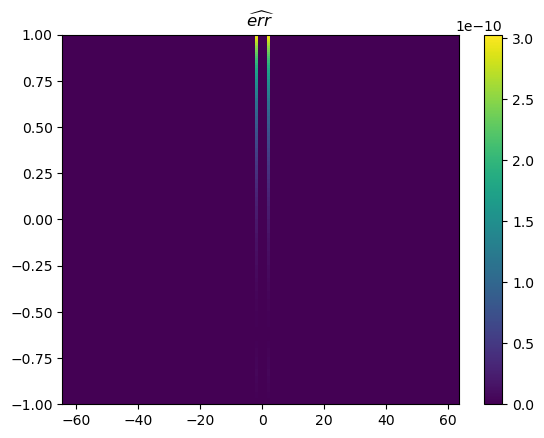

<Figure size 640x480 with 0 Axes>

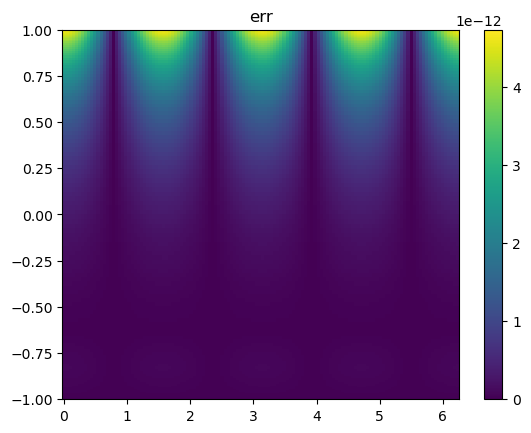

In [50]:
#Réimplémentation
kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (x_sup - x_inf)/Nx)


psi_num_hat_test = np.zeros((Nx, Ny), dtype='complex')
psi_num_test = np.zeros((Nx, Ny), dtype='complex')
rhs_hat_test = scipy.fft.fft(rhs_2, axis = 0)

bc_y1_2_hat = scipy.fft.fft(bc_y1_2)
bc_ym1_2_hat = scipy.fft.fft(bc_ym1_2)

D = Chebyshev.Cheb_mat(Ny)
D2 = D@D

for i in range(0, kx.size):
    
    F = -( alpha2_2 + kx[i]**2 )*np.eye(Ny)
    F[0, 0] = 1.0
    F[-1, -1] = 1.0
    F[1:-1, :] += D2[1:-1, :]
    rhs_hat_i = rhs_hat_test[i, :].copy()
    rhs_hat_i[0] = bc_y1_2_hat[i].copy()
    rhs_hat_i[-1] = bc_ym1_2_hat[i].copy()
    inv_F = np.linalg.inv(F)
    psi_num_hat_test[i, :] = inv_F @rhs_hat_i

psi_ana_hat = scipy.fft.fft(psi_analytique_2, axis=0)

err_hat_test = np.abs(psi_ana_hat.real - psi_num_hat_test.real)

psi_num_test = scipy.fft.ifft(psi_num_hat_test, axis =0)
err_num_test = np.abs(psi_num_test - psi_analytique_2)

print(f"err_hat_test : mediane = {np.median(err_hat_test)}, max = {err_hat_test.max()}, min = {err_hat_test.min()}")
print(f"err_num_test : mediane = {np.median(err_num_test)}, max = {err_num_test.max()}, min = {err_num_test.min()}")


Kx, Y = np.meshgrid(np.sort(kx), y, indexing = 'ij')
fig  = plt.figure()
ax=plt.axes()
ax.set_title(r"$\widehat{err}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(err_hat_test, kx)))
fig.colorbar(cf, ax=ax)

fig= plt.figure()
fig  = plt.figure()
ax=plt.axes()
ax.set_title(r"err")
cf = ax.pcolormesh(X, Y, err_num_test)
fig.colorbar(cf, ax=ax)


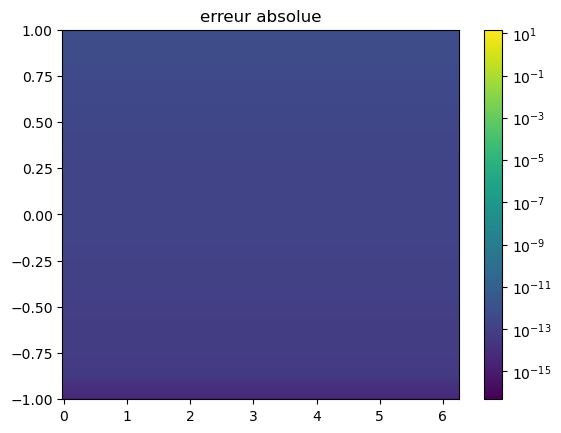

In [17]:
#cas psi(x, y = 1.0)
sol_ana = 1.0*np.ones((Nx, Ny))
psi_num_3 = Solve_Helmholtz(Nx,
                            Ny,
                            alpha2 = 3.0,
                            rhs = -3.0,
                            CL_y_inf = 1.0,
                            CL_y_sup = 1.0,
                            interval_x = (x_inf, x_sup),
                            interval_y = (y_inf, y_sup)
                           )
fig = plt.figure()
err_3 = np.abs(sol_ana-psi_num_3)
ax=plt.axes()
ax.set_title("erreur absolue")
try:
    cf = ax.pcolormesh(X, Y, err_3, norm=colors.LogNorm(vmin=err_2.min(), vmax=err_2.max()))
except ValueError:
    cf = ax.pcolormesh(X, Y, err_3, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)

In [18]:
sort_k(rhs_hat_2, kx).shape

(128, 128)

In [19]:
(l**2-k**2 - alpha2_2)*psi_analytique_2 - rhs_2

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.77635684e-15,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  1.77635684e-15],
       ...,
       [-1.77635684e-15,  1.77635684e-15,  1.77635684e-15, ...,
         1.77635684e-15,  1.77635684e-15, -1.77635684e-15],
       [ 0.00000000e+00,  0.00000000e+00,  1.77635684e-15, ...,
         1.77635684e-15,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.77635684e-15, ...,
         1.77635684e-15,  0.00000000e+00,  0.00000000e+00]])

FFT(x) = [-4.82703475e-15-0.00000000e+00j  6.40000000e+01-7.57240132e-15j
  1.30105488e-15+4.86923310e-16j -1.82078990e-17+1.61171036e-16j
  4.28814466e-16-1.12473124e-15j -7.53882378e-16+2.50419992e-16j
  8.21968320e-16+8.95712586e-16j -5.00599553e-16-6.81633037e-17j
 -1.23686449e-16-4.48678419e-16j  2.44711028e-15+8.64727602e-16j
  2.61354960e-16-2.12861325e-16j  1.35036477e-15+2.47604321e-16j
  5.52849771e-16+9.60134008e-16j -4.71051699e-16-4.67609543e-16j
 -6.74088817e-16-1.07909296e-15j -1.50752204e-17+1.31185390e-15j
 -4.49374695e-16-2.68684361e-17j  1.22341172e-15-1.80558181e-16j
  5.49904272e-16+5.31414111e-16j -1.74732784e-15-1.19539230e-15j
  3.56385749e-16-5.71417271e-16j -8.83747444e-16-4.44314918e-16j
  2.26322835e-16-1.86367227e-15j  3.17417976e-15+1.36169645e-15j
  3.63568868e-16+5.02024281e-15j -4.30304461e-15+1.58838651e-15j
  1.77209034e-16-2.23449281e-15j  8.29992916e-16+5.08590994e-16j
 -5.98243775e-16+1.02922045e-15j  3.46835027e-17-4.96760740e-16j
 -9.71569594e-16

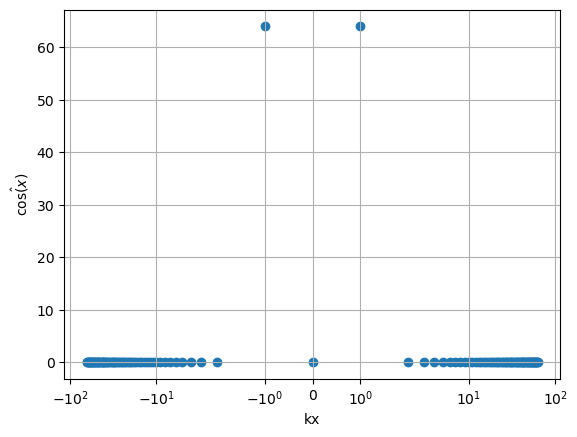

In [20]:
N = 128
xx = np.linspace(0.0, 2.0*np.pi, N, endpoint = False)

cos_x = np.cos(x)
cos_x_hat = scipy.fft.fft(cos_x)
print(f"FFT(x) = {cos_x_hat}")
kxx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = 2.0*np.pi/N)
arg_max_x = np.argmax(cos_x_hat)
print(f"kxx = {kxx}")

print(f"amplitude max {np.abs(cos_x_hat).max()} en kxx = {kxx[arg_max_x]}")


fig = plt.figure()
kx_sorted = np.sort(kxx)
plt.scatter(kx_sorted, sort_k(cos_x_hat.real, kxx), label = r"CL_sup")
plt.xlabel("kx")
plt.ylabel(r"$\hat{\cos(x)}$")

plt.xscale('symlog')
#plt.yscale('log')
plt.grid(True)

for i in range(0, kxx.size):
    if np.abs(cos_x_hat[i]) > 1.0e-12 : 
        print(f"mode d'amplitude {cos_x_hat[i]} en kxx = {kxx[i]}")

In [21]:
np.pi/4.0

0.7853981633974483

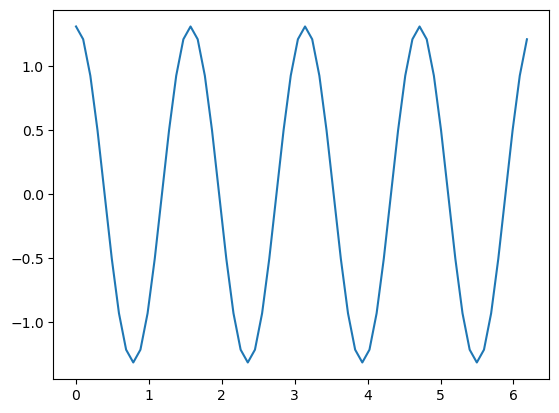

In [22]:
#test avec mode k=2 artificiel
N=64
N_mode = 4
psi_hat_test =np.zeros(N, dtype = 'complex')
psi_hat_test[N_mode] = 42.0+0.0j
psi_hat_test[N-N_mode] = 42.0+0.0j
psi_test = scipy.fft.ifft(psi_hat_test)

kk = scipy.fft.fftfreq(N, d = 2.0*np.pi/N)*2.0*np.pi
xx = np.linspace(0.0, 2.0*np.pi, N, endpoint = False)

fig = plt.figure()
plt.plot(xx, psi_test.real)

[0.00000000e+00 1.77635684e-15 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.55271368e-15 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.77635684e-15
 2.66453526e-15 8.88178420e-16 8.88178420e-16 6.66133815e-16
 7.88860905e-31 2.22044605e-16 0.00000000e+00 4.44089210e-16
 0.00000000e+00 1.77635684e-15 8.88178420e-16 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.77635684e-15
 0.00000000e+00 3.55271368e-15 0.00000000e+00 3.55271368e-15
 0.00000000e+00 1.77635684e-15 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.55271368e-15 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.77635684e-15
 2.66453526e-15 8.88178420e-16 8.88178420e-16 6.66133815e-16
 7.88860905e-31 2.22044605e-16 0.00000000e+00 4.44089210e-16
 0.00000000e+00 1.77635684e-15 8.88178420e-16 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.77635684e-15
 0.00000000e+00 3.55271368e-15 0.00000000e+00 3.55271368e-15
 0.00000000e+00 1.776356

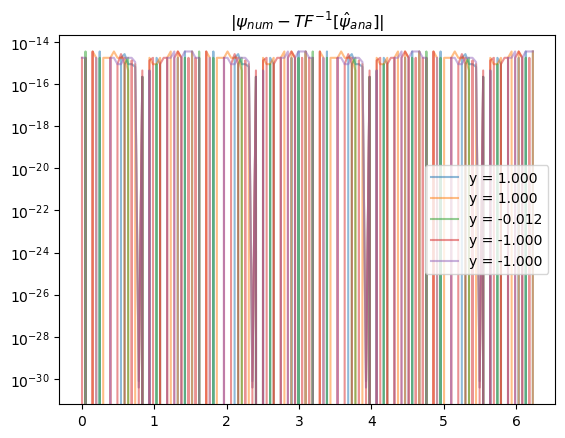

In [23]:
#test de l'ifft sur une ligne

liste_j = [0, 1, Ny//2, Ny-2, Ny-1]

fig = plt.figure()
for j in range(0, len(liste_j)): 
    err_i = np.abs(psi_num_2[:, j] - scipy.fft.ifft(psi_num_hat_2[:, j]).real)
    print(err_i)
    plt.plot(x, err_i, label = f"y = {y[liste_j[j]]:.3f}", alpha =0.5)
plt.yscale('log')
plt.title(r"$|\psi_{num} - TF^{-1}[\hat{\psi}_{ana}]|$")
plt.legend()

In [73]:
%timeit Solve_Helmholtz(Nx, Ny, alpha2 = alpha2_2, rhs = rhs_2, CL_y_inf = bc_ym1_2, CL_y_sup = bc_y1_2, interval_x = (x_inf, x_sup), interval_y = (y_inf, y_sup) )

kx = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62. -61. -60. -59.
 -58. -57. -56. -55. -54. -53. -52. -51. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]
RHS array
CL_inf array
CL_sup array
kx = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59